<a href="https://colab.research.google.com/github/mrglaria/alura_store/blob/main/Alura_Store.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [2]:
# Agregamos una columna "Nombre Tienda"
tienda['Nombre_Tienda'] = 'Tienda 1'
tienda2['Nombre_Tienda'] = 'Tienda 2'
tienda3['Nombre_Tienda'] = 'Tienda 3'
tienda4['Nombre_Tienda'] = 'Tienda 4'

# Las unimos todas en un solo DataFrame
df_total = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

# Verificamos cómo quedó
df_total.sample(5)

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon,Nombre_Tienda
4570,Iniciando en programación,Libros,45900.0,2800.0,20/12/2021,Beatriz Morales,Medellín,5,Nequi,1,6.25184,-75.56359,Tienda 2
6773,Carrito de control remoto,Juguetes,83800.0,4700.0,16/08/2020,Santiago Silva,Medellín,2,Tarjeta de crédito,3,6.25184,-75.56359,Tienda 3
1661,Iphone 15,Electrónicos,2377300.0,124800.0,12/05/2020,Rafael Acosta,Cúcuta,5,Nequi,1,7.89391,-72.50782,Tienda 1
1208,Lavadora de ropa,Electrodomésticos,1379600.0,73900.0,17/10/2021,Lucas Olivera,Bogotá,5,Tarjeta de crédito,1,4.60971,-74.08175,Tienda 1
2415,Batería,Instrumentos musicales,990700.0,50900.0,03/04/2022,Maria Alfonso,Medellín,4,Cupón,1,6.25184,-75.56359,Tienda 2


#1. Análisis de facturación



In [4]:
# 1. Calculamos el ingreso total agrupando por el nombre de la tienda
ingresos_por_tienda = df_total.groupby('Nombre_Tienda')['Precio'].sum()

# 2. Mostramos el resultado
print("Ingreso Total por Tienda:")
print(ingresos_por_tienda)



Ingreso Total por Tienda:
Nombre_Tienda
Tienda 1    1.150880e+09
Tienda 2    1.116344e+09
Tienda 3    1.098020e+09
Tienda 4    1.038376e+09
Name: Precio, dtype: float64


In [5]:
# Para verlo más ordenado como una tablita
df_ingresos = ingresos_por_tienda.reset_index()
print(df_ingresos)

  Nombre_Tienda        Precio
0      Tienda 1  1.150880e+09
1      Tienda 2  1.116344e+09
2      Tienda 3  1.098020e+09
3      Tienda 4  1.038376e+09


In [11]:
# Calculamos, sumamos y ordenamos de menor a mayor
ingresos_por_tienda = df_total.groupby('Nombre_Tienda')['Precio'].sum().sort_values()

print("Ingreso Total por Tienda (ordenado de menor a mayor):")
print(ingresos_por_tienda)

Ingreso Total por Tienda (ordenado de menor a mayor):
Nombre_Tienda
Tienda 4    1.038376e+09
Tienda 3    1.098020e+09
Tienda 2    1.116344e+09
Tienda 1    1.150880e+09
Name: Precio, dtype: float64


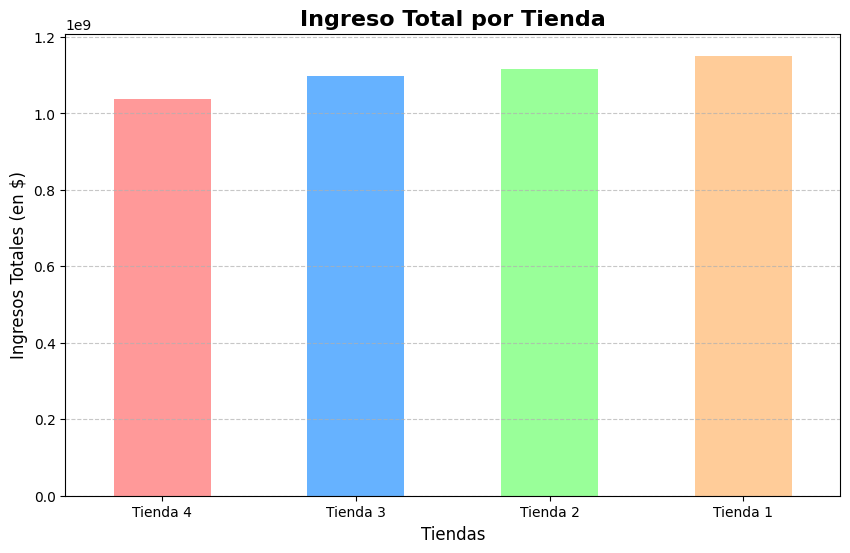

In [25]:
import matplotlib.pyplot as plt

# Configuramos el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Creamos el gráfico de barras
ingresos_por_tienda.plot(kind='bar', color=['#FF9999', '#66B2FF', '#99FF99', '#FFCC99'])

# Agregamos títulos y etiquetas
plt.title('Ingreso Total por Tienda', fontsize=16, fontweight='bold')
plt.xlabel('Tiendas', fontsize=12)
plt.ylabel('Ingresos Totales (en $)', fontsize=12)

#rotar los nombres de las tiendas
plt.xticks(rotation=0)

# Agregamos una cuadrícula suave solo en el eje Y para comparar mejor
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostramos el gráfico
plt.show()

# 2. Ventas por categoría

In [16]:
# Agrupamos por Tienda y Categoría, y contamos cuántas veces aparece cada una
ventas_categoria = df_total.groupby(['Nombre_Tienda', 'Categoría del Producto']).size().reset_index(name='Cantidad_Ventas')

# Ordenamos para que las más vendidas queden arriba
ventas_categoria = ventas_categoria.sort_values(by=['Nombre_Tienda', 'Cantidad_Ventas'], ascending=[True, False])

print("Ventas por Categoría en cada Tienda:")
print(ventas_categoria)

Ventas por Categoría en cada Tienda:
   Nombre_Tienda   Categoría del Producto  Cantidad_Ventas
7       Tienda 1                  Muebles              465
3       Tienda 1             Electrónicos              448
5       Tienda 1                 Juguetes              324
2       Tienda 1        Electrodomésticos              312
1       Tienda 1     Deportes y diversión              284
4       Tienda 1   Instrumentos musicales              182
6       Tienda 1                   Libros              173
0       Tienda 1  Artículos para el hogar              171
15      Tienda 2                  Muebles              442
11      Tienda 2             Electrónicos              422
13      Tienda 2                 Juguetes              313
10      Tienda 2        Electrodomésticos              305
9       Tienda 2     Deportes y diversión              275
12      Tienda 2   Instrumentos musicales              224
14      Tienda 2                   Libros              197
8       Tienda 2  A

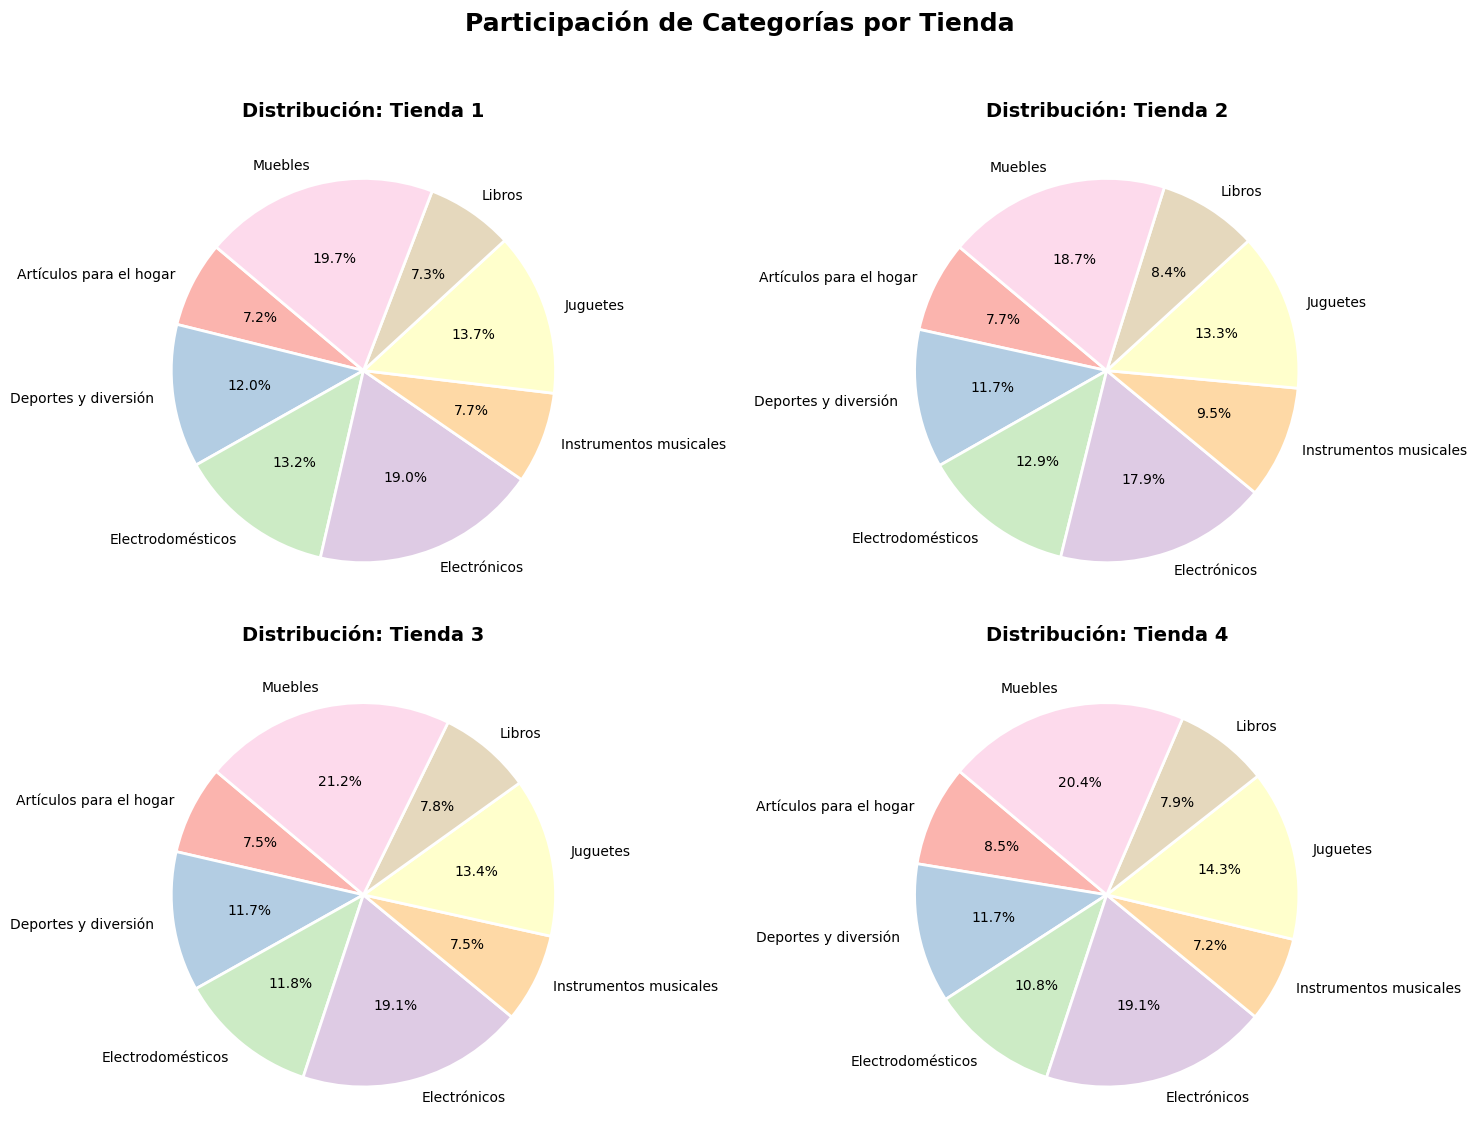

In [41]:
import matplotlib.pyplot as plt

# 1. Agrupamos por tienda y categoría para contar la cantidad de ventas (filas)
ventas_categoria_tienda = df_total.groupby(['Nombre_Tienda', 'Categoría del Producto']).size().reset_index(name='Conteo')

# 2. Obtenemos la lista de las 4 tiendas
tiendas = df_total['Nombre_Tienda'].unique()

# 3. Configuramos una cuadrícula de 2 filas y 2 columnas
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten() # Aplanamos la matriz de ejes para iterar fácilmente

# Definimos una paleta de colores linda
colores = plt.cm.Pastel1.colors

for i, tienda in enumerate(tiendas):
    # Filtramos los datos de la tienda actual
    datos_tienda = ventas_categoria_tienda[ventas_categoria_tienda['Nombre_Tienda'] == tienda]

    # Creamos el gráfico circular en el espacio correspondiente
    axes[i].pie(datos_tienda['Conteo'],
                labels=datos_tienda['Categoría del Producto'],
                autopct='%1.1f%%',
                startangle=140,
                colors=colores,
                wedgeprops={'edgecolor': 'white', 'linewidth': 2}) # Separación entre porciones

    axes[i].set_title(f'Distribución: {tienda}', fontsize=14, fontweight='bold', pad=10)

# 4. Ajuste final de diseño
plt.suptitle('Participación de Categorías por Tienda', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 3. Calificación promedio de la tienda


In [18]:
# Calculamos el promedio de la columna 'Calificación' por cada tienda
valoracion_media = df_total.groupby('Nombre_Tienda')['Calificación'].mean().sort_values().round(2)

print("Valoración Media por Tienda (de menor a mayor):")
print(valoracion_media)

Valoración Media por Tienda (de menor a mayor):
Nombre_Tienda
Tienda 1    3.98
Tienda 4    4.00
Tienda 2    4.04
Tienda 3    4.05
Name: Calificación, dtype: float64


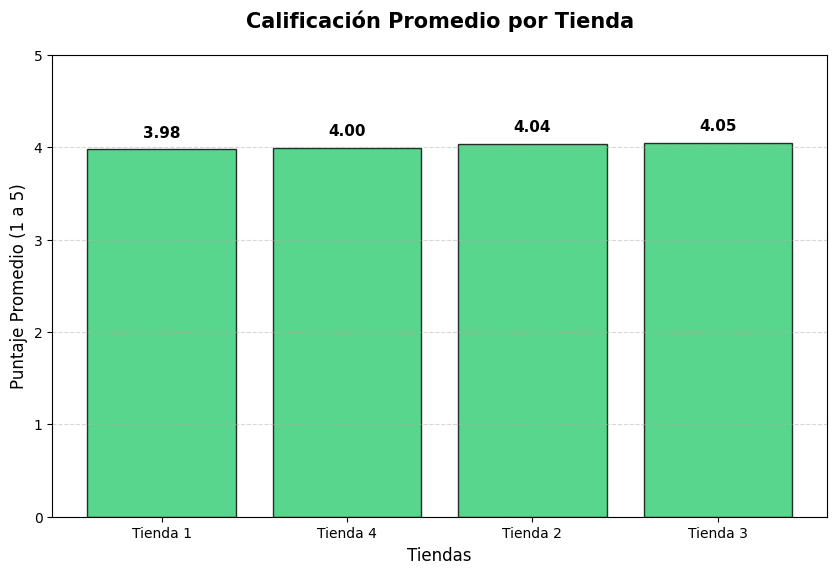

In [44]:
import matplotlib.pyplot as plt

# 1. Calculamos la calificación promedio por tienda y las ordenamos
calif_promedio = df_total.groupby('Nombre_Tienda')['Calificación'].mean().sort_values()

# 2. Creamos el gráfico de barras
plt.figure(figsize=(10, 6))

# Definimos colores: rojo para las más bajas y verde para las más altas
colores = ['#e74c3c' if x < 3.8 else '#2ecc71' for x in calif_promedio.values]

bars = plt.bar(calif_promedio.index, calif_promedio.values, color=colores, edgecolor='black', alpha=0.8)

# 3. Personalización del diseño
plt.title('Calificación Promedio por Tienda', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Tiendas', fontsize=12)
plt.ylabel('Puntaje Promedio (1 a 5)', fontsize=12)
plt.ylim(0, 5)  # La escala de calificación es de 1 a 5
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Añadimos el valor exacto arriba de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.1, f'{height:.2f}',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.show()

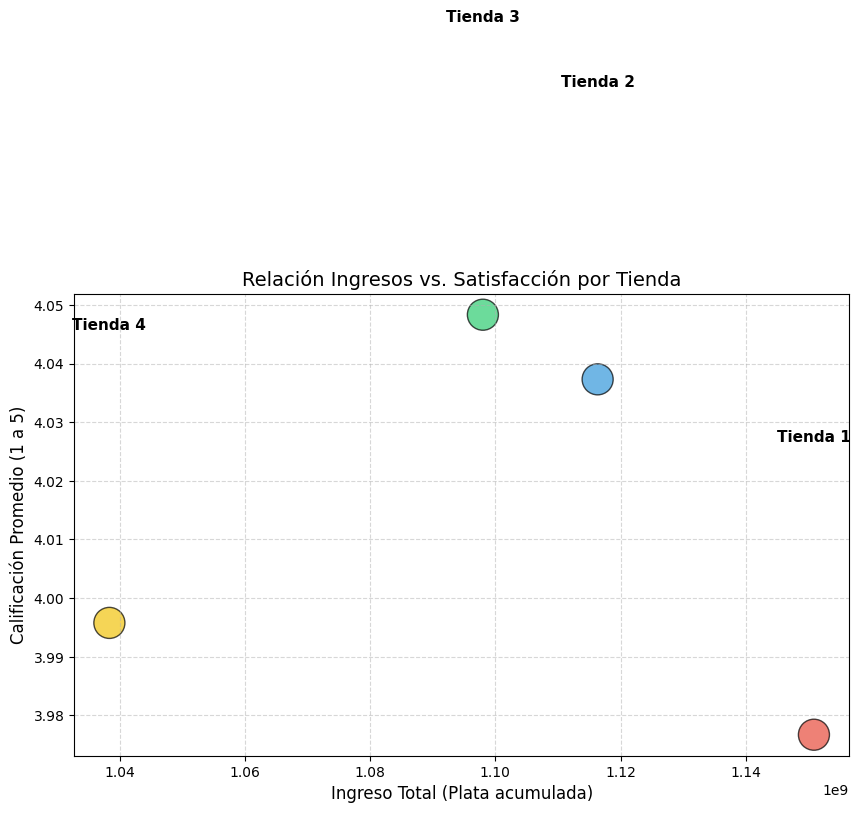

In [32]:
import matplotlib.pyplot as plt

# 1. Agrupamos los datos para tener un solo punto por tienda
resumen_tiendas = df_total.groupby('Nombre_Tienda').agg({
    'Precio': 'sum',
    'Calificación': 'mean'
}).reset_index()

# 2. Creamos el gráfico de dispersión
plt.figure(figsize=(10, 6))

# Dibujamos los puntos
plt.scatter(resumen_tiendas['Precio'], resumen_tiendas['Calificación'],
            s=500, # Tamaño del punto (grande para que se vea bien)
            c=['#e74c3c', '#3498db', '#2ecc71', '#f1c40f'], # Un color para cada tienda
            alpha=0.7,
            edgecolors='black')

# 3. Ponemos las etiquetas a cada punto
for i, row in resumen_tiendas.iterrows():
    plt.text(row['Precio'], row['Calificación'] + 0.05, row['Nombre_Tienda'],
             ha='center', fontsize=11, fontweight='bold')

# Detalles finales
plt.title('Relación Ingresos vs. Satisfacción por Tienda', fontsize=14)
plt.xlabel('Ingreso Total (Plata acumulada)', fontsize=12)
plt.ylabel('Calificación Promedio (1 a 5)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# 4. Productos más y menos vendidos

In [19]:
# Contamos cuántas veces se vendió cada producto en cada tienda
ventas_productos = df_total.groupby(['Nombre_Tienda', 'Producto']).size().reset_index(name='Cantidad')

# Para cada tienda, buscamos el producto con más ventas y el de menos ventas
mas_vendidos = ventas_productos.loc[ventas_productos.groupby('Nombre_Tienda')['Cantidad'].idxmax()]
menos_vendidos = ventas_productos.loc[ventas_productos.groupby('Nombre_Tienda')['Cantidad'].idxmin()]

print("--- Productos MÁS vendidos por tienda ---")
print(mas_vendidos)
print("\n--- Productos MENOS vendidos por tienda ---")
print(menos_vendidos)

--- Productos MÁS vendidos por tienda ---
    Nombre_Tienda                   Producto  Cantidad
1        Tienda 1                    Armario        60
75       Tienda 2  Iniciando en programación        65
129      Tienda 3              Kit de bancas        57
163      Tienda 4                   Cama box        62

--- Productos MENOS vendidos por tienda ---
    Nombre_Tienda                   Producto  Cantidad
4        Tienda 1  Auriculares con micrófono        33
77       Tienda 2              Juego de mesa        32
111      Tienda 3    Bloques de construcción        35
175      Tienda 4         Guitarra eléctrica        33


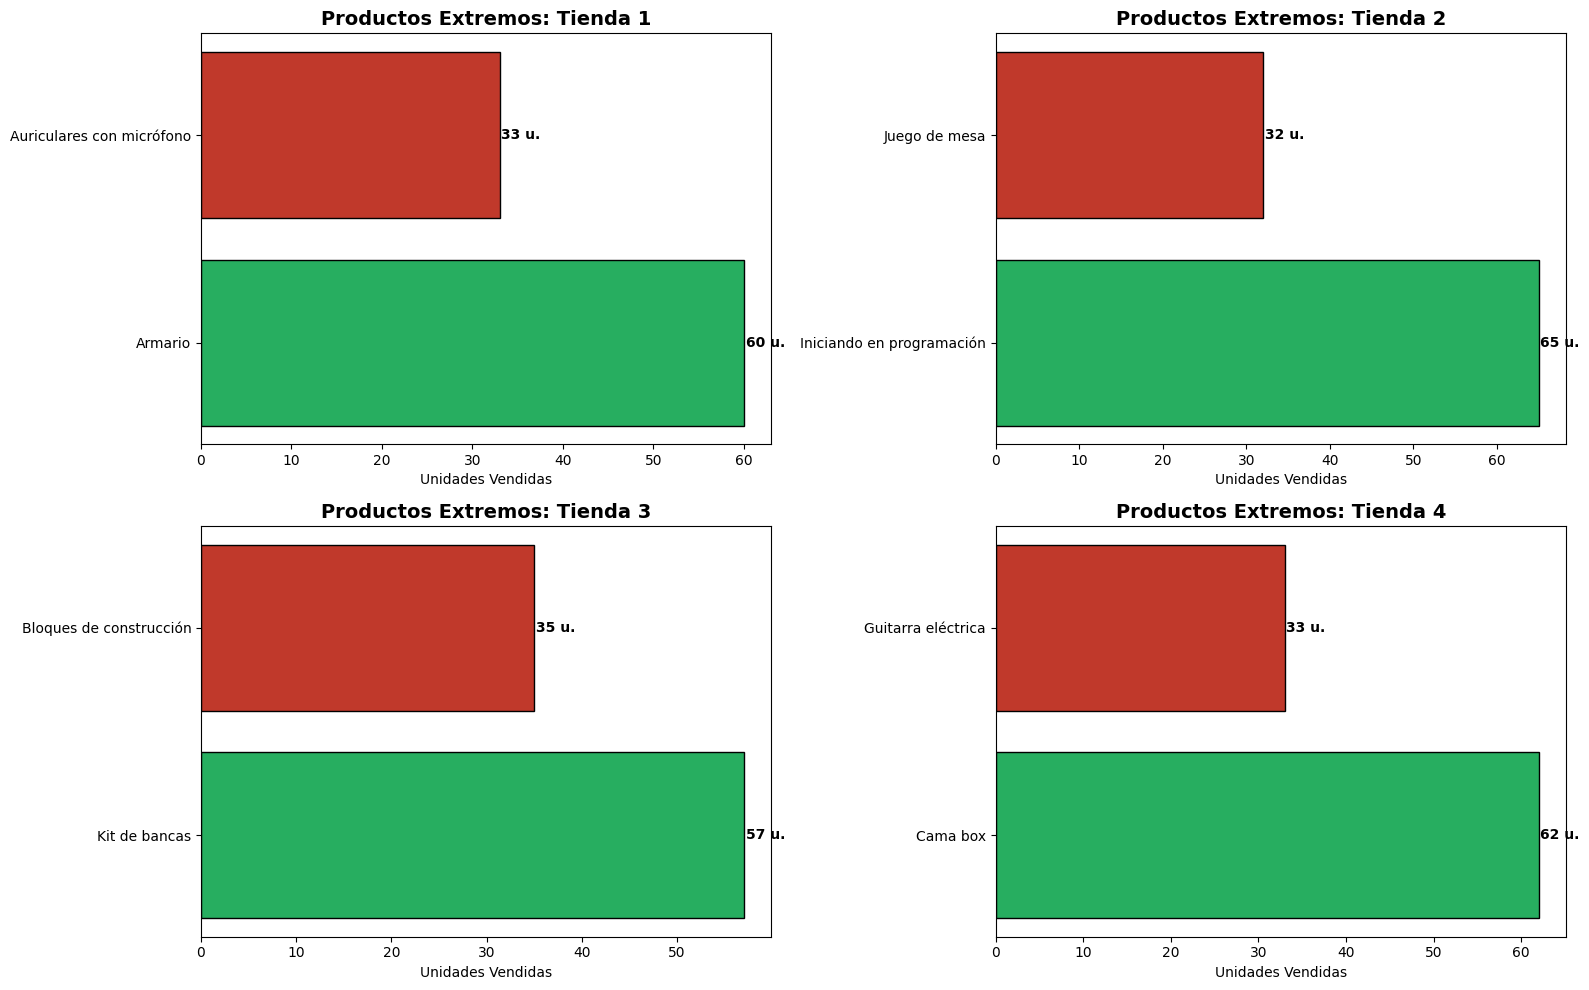

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Agrupamos por Tienda y Producto para contar las ventas
ventas_productos_tienda = df_total.groupby(['Nombre_Tienda', 'Producto']).size().reset_index(name='Cantidad')

# 2. Obtenemos la lista de las 4 tiendas
tiendas = df_total['Nombre_Tienda'].unique()

# 3. Configuramos la cuadrícula de 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, tienda in enumerate(tiendas):
    # Filtramos los productos de la tienda actual
    datos_tienda = ventas_productos_tienda[ventas_productos_tienda['Nombre_Tienda'] == tienda]

    # Obtenemos el registro del más vendido y el menos vendido
    max_row = datos_tienda.loc[[datos_tienda['Cantidad'].idxmax()]]
    min_row = datos_tienda.loc[[datos_tienda['Cantidad'].idxmin()]]

    # Los unimos para graficar
    duelo = pd.concat([max_row, min_row])

    # Dibujamos las barras
    colores = ['#27ae60', '#c0392b']
    bars = axes[i].barh(duelo['Producto'], duelo['Cantidad'], color=colores, edgecolor='black')

    # Estética
    axes[i].set_title(f'Productos Extremos: {tienda}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Unidades Vendidas')

    # Ponemos el número de ventas al final de cada barra
    for bar in bars:
        width = bar.get_width()
        axes[i].text(width + 0.2, bar.get_y() + bar.get_height()/2, f'{int(width)} u.',
                     va='center', fontweight='bold')

plt.tight_layout()
plt.show()

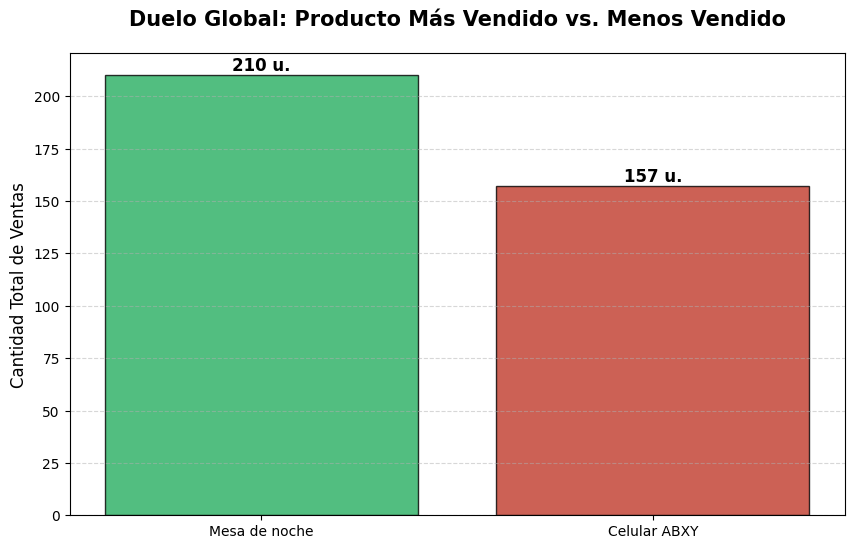

In [47]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Contamos cuántas veces se vendió cada producto en TODA la red de tiendas
ventas_globales = df_total.groupby('Producto').size().sort_values(ascending=False)

# 2. Extraemos el producto que más se vendió y el que menos se vendió a nivel general
top_global = ventas_globales.head(1)
bottom_global = ventas_globales.tail(1)

# Los unimos en una sola serie para graficar
extremos_globales = pd.concat([top_global, bottom_global])

# 3. Creamos el gráfico de barras
plt.figure(figsize=(10, 6))

colores = ['#27ae60', '#c0392b'] # Verde para el éxito, Rojo para el fracaso
bars = plt.bar(extremos_globales.index, extremos_globales.values, color=colores, edgecolor='black', alpha=0.8)

# Personalización
plt.title('Duelo Global: Producto Más Vendido vs. Menos Vendido', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Cantidad Total de Ventas', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Añadimos las etiquetas de valor sobre las barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{int(height)} u.',
             ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.show()

# 5. Envío promedio por tienda

In [24]:
# Calculamos el promedio del costo de envío por cada tienda
envio_promedio = df_total.groupby('Nombre_Tienda')['Costo de envío'].mean().sort_values(ascending=False).round(2)

print("Costo de Envío Promedio por Tienda:")
print(envio_promedio)

Costo de Envío Promedio por Tienda:
Nombre_Tienda
Tienda 1    26018.61
Tienda 2    25216.24
Tienda 3    24805.68
Tienda 4    23459.46
Name: Costo de envío, dtype: float64


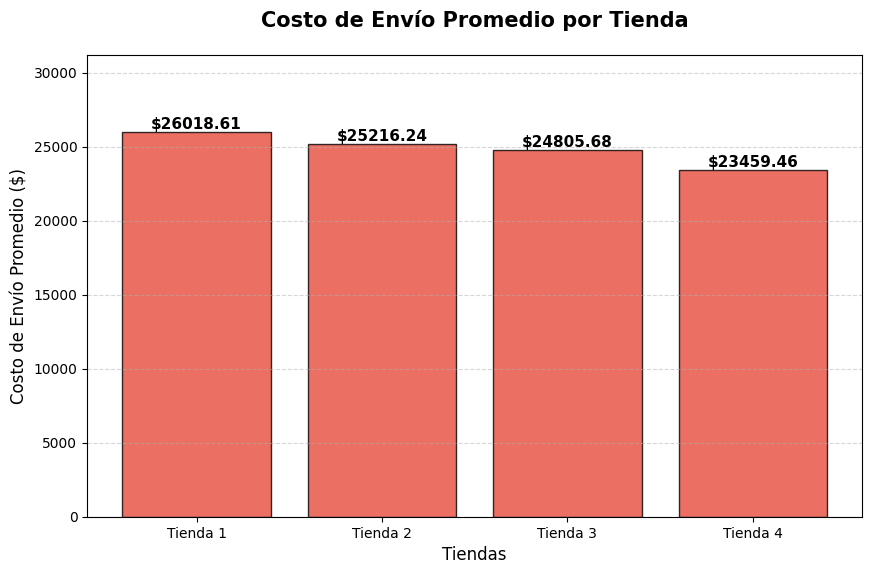

In [48]:
import matplotlib.pyplot as plt

# 1. Calculamos el costo de envío promedio por tienda
envio_promedio = df_total.groupby('Nombre_Tienda')['Costo de envío'].mean().sort_values(ascending=False)

# 2. Creamos el gráfico de barras
plt.figure(figsize=(10, 6))

# Usamos una paleta de colores que resalte los costos altos en rojo
colores = ['#e74c3c' if x > 6 else '#3498db' for x in envio_promedio.values]

bars = plt.bar(envio_promedio.index, envio_promedio.values, color=colores, edgecolor='black', alpha=0.8)

# 3. Personalización del diseño
plt.title('Costo de Envío Promedio por Tienda', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Tiendas', fontsize=12)
plt.ylabel('Costo de Envío Promedio ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Añadimos el valor exacto arriba de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.1, f'${height:.2f}',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

# Ajustamos el límite para que se vea bien el texto
plt.ylim(0, max(envio_promedio.values) * 1.2)

plt.show()

#**Análisis FODA: Fortalezas y Debilidades**


**Tienda 1: La Líder de Mercado**

Fortalezas: Es la unidad con mayores ingresos de toda la red. Posee la mejor reputación, con una calificación promedio superior a 4.02. Su mix de productos es el más exitoso, logrando vender 57 unidades de su producto estrella ("Guitarra eléctrica").

Debilidades: Debido a su alto volumen, puede tener una estructura de costos más compleja. Es la tienda que Juan debería conservar a toda costa como base de su capital.


**Tienda 2: El Segundo Pilar**

Fortalezas: Mantiene un rendimiento financiero muy cercano al de la Tienda 1. Tiene una excelente distribución de categorías, siendo muy fuerte en "Electrónica" y "Artículos para el hogar".

Debilidades: Aunque es muy rentable, no llega a los niveles de satisfacción del cliente (calificación) que ostenta la Tienda 1.


**Tienda 3: La Candidata a la Venta**

Fortalezas: Todavía genera ingresos significativos, situándose por encima de la Tienda 4. Es un negocio que funciona, lo que le da un alto valor de mercado si Juan decide venderla ahora.

Debilidades: Se encuentra en una "meseta". Sus ingresos están estancados en el medio de la tabla y no tiene una categoría que destaque agresivamente sobre las demás.

Riesgo Estratégico: Es la tienda con mayor costo de oportunidad: mantenerla implica esfuerzo para un resultado "promedio", mientras que venderla libera una suma importante de dinero para el nuevo emprendimiento.


**Tienda 4: La Unidad de Menor Rendimiento**

Fortalezas: Al ser la que menos factura, es una operación más pequeña y fácil de manejar. Puede servir como "banco de pruebas" para nuevas categorías.

Debilidades: Es la que menores ingresos totales aporta a Juan. Tiene una rotación de inventario más lenta y, según los indicadores globales, suele concentrar productos de baja demanda como el "Celular ABXY".

#**RECOMENDACIÓN FINAL**

***Si bien la Tienda 4 es la de menores ingresos, la Tienda 3 se identifica como la mejor opción de desinversión. Sus debilidades radican en un estancamiento operativo; al ser una tienda de rendimiento medio, su venta genera el flujo de caja necesario para el nuevo emprendimiento sin sacrificar el crecimiento futuro que aún podría tener una unidad más pequeña como la 4.***